In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

# Load my data

In [3]:
bands = [4, 5, 6, 7]


all_bands    = ["Band 4 nterms2",  "Band 5 robust -1",     "Band 6", "Band 7 nterms2"]
bands_naming = ['Band4_nterms2',   "Band5_robust_minus1",  'Band6',  'Band7_nterms2']
bands_labels = ['Band 4 test',          "Band 5",      'Band 6', 'Band 7']

band_to_index = {band: i for i, band in enumerate(all_bands)}

wavelengths = [lambda_mm[band] for band in bands]
lambda_bands_cm = mm_to_cm(wavelengths)
print(lambda_bands_cm)

colours = [alma_band_colors[band] for band in bands]

[0.21  0.15  0.13  0.087]


In [4]:

f_values_all = [1, 0.75, 0.6, 0.5, 0.3, 0.25, 0.1, 0.01]
f_values = [1, 0.5, 0.3, 0.1]
f_values_extra =  [0.75, 0.6, 0.25, 0.01]

colours = [alma_band_colors[band] for band in bands]


prefix = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ZHANG_CODE/MY_npz_files/"

band_prefix = {
    4: 'BAND4/',
    5: 'BAND5/',
    6: 'BAND6/',
    7: 'BAND7/',
}


file_names = {
    '1'   : "dsharp_results_ff_1.00_smoothed_extrapol.npz",
    '0.75': "dsharp_results_ff_0.75_smoothed_extrapol.npz",
    '0.6': "dsharp_results_ff_0.60_smoothed_extrapol.npz",   
    '0.5': "dsharp_results_ff_0.50_smoothed_extrapol.npz",    
    '0.3': "dsharp_results_ff_0.30_smoothed_extrapol.npz",    
    '0.25': "dsharp_results_ff_0.25_smoothed_extrapol.npz",  
    '0.1': "dsharp_results_ff_0.10_smoothed_extrapol.npz", 
    '0.01': "dsharp_results_ff_0.01_smoothed_extrapol.npz"   
}


# Make an array to store the data
data = {}




for band, wav in zip(bands, wavelengths):
    data[wav] = {}

    for f in f_values_all:
        filename = prefix + band_prefix[band] + file_names[str(f)]
        d = np.load(filename)
        
        data[wav][str(f)] = do_things(d)

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.2e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.1e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 8.5e+02%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.5e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.4e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:21

In [5]:
df = pd.DataFrame({
    "a_max_micron": data[lambda_mm[4]][str(f)]["a"] * 1e4,
    "P_Band 4": data[lambda_mm[4]][str(f)]["P"],
    "omega_Band 4": data[lambda_mm[4]][str(f)]["omega_eff"],
    "P_times_omega_Band 4": data[lambda_mm[4]][str(f)]["P_omega_eff"],

    "P_Band5": data[lambda_mm[5]][str(f)]["P"],
    "omega_Band5": data[lambda_mm[5]][str(f)]["omega_eff"],
    "P_times_omega_Band5": data[lambda_mm[5]][str(f)]["P_omega_eff"],

    "P_Band6": data[lambda_mm[6]][str(f)]["P"],
    "omega_Band6": data[lambda_mm[6]][str(f)]["omega_eff"],
    "P_times_omega_Band6": data[lambda_mm[6]][str(f)]["P_omega_eff"],

    "P_Band7": data[lambda_mm[7]][str(f)]["P"],
    "omega_Band7": data[lambda_mm[7]][str(f)]["omega_eff"],
    "P_times_omega_Band7": data[lambda_mm[7]][str(f)]["P_omega_eff"],
})

In [6]:
df_POLF = load_POLF(all_bands, print_things = True, bias = 'debiased')

df_POLF.round(2)

Band = Band 4 nterms2
filename = constants_BAND4_nterms2_debiased.csv
['POLF_Gaussian', 'POLF_err_Gaussian', 'POLF_maxPOLI', 'POLF_err_maxPOLI', 'POLF_maxStokesI', 'POLF_err_maxStokesI']
Band = Band 5 robust -1
filename = constants_BAND5_robust_minus1_debiased.csv
['POLF_Gaussian', 'POLF_err_Gaussian', 'POLF_maxPOLI', 'POLF_err_maxPOLI', 'POLF_maxStokesI', 'POLF_err_maxStokesI']
Band = Band 6
filename = constants_BAND6_debiased.csv
['POLF_Gaussian', 'POLF_err_Gaussian', 'POLF_maxPOLI', 'POLF_err_maxPOLI', 'POLF_maxStokesI', 'POLF_err_maxStokesI']
Band = Band 7 nterms2
filename = constants_BAND7_nterms2_debiased.csv
['POLF_Gaussian', 'POLF_err_Gaussian', 'POLF_maxPOLI', 'POLF_err_maxPOLI', 'POLF_maxStokesI', 'POLF_err_maxStokesI']
 in load_POLF, results = {'Band': ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2'], 'POLF_Gaussian': [1.1638928, 1.3484494, 1.41269695, 0.8981155], 'POLF_err_Gaussian': [0.040598361141059996, 0.0765298153593, 0.030886987, 0.01717186472986], '

,Band,POLF_Gaussian,POLF_err_Gaussian,POLF_maxPOLI,POLF_err_maxPOLI,POLF_maxStokesI,POLF_err_maxStokesI,POLF_mean
0,Band 4 nterms2,1.16,0.04,1.56,0.04,1.37,0.04,0.70
1,Band 5 robust -1,1.35,0.08,1.51,0.07,1.40,0.07,0.75
2,Band 6,1.41,0.03,1.49,0.03,1.46,0.03,0.74
3,Band 7 nterms2,0.90,0.02,1.08,0.02,1.04,0.01,0.51


In [7]:
df_POLF


POLF_type = 'POLI'
plot_sf = 1.5

polf_columns = {
    'gaussian': 'POLF_Gaussian',
    'max Stokes I': 'POLF_maxStokesI',
    'max Stokes I err': 'POLF_err_maxStokesI',
    'POLI': 'POLF_maxPOLI',
    'POLI_err': 'POLF_err_maxPOLI',
    'mean': 'POLF_mean'
}

POLF_obs_all = df_POLF[polf_columns[POLF_type]].values

POLF_obs_for_plot = dict(zip(df_POLF["Band"], df_POLF["POLF_maxPOLI"]))
POLF_err_obs_for_plot = dict(zip(df_POLF["Band"], df_POLF["POLF_err_maxPOLI"]))

## All bands

In [8]:
bands_fit = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]

fit_indices_all = [band_to_index[b] for b in bands_fit]


a_max_dist_micron_all, P_times_omega_all, a_max_best_all, POLF_obs_all, best_sf_all, best_idx_all, chi_sq_all, chi_sq_reduced_all, df_best_all = find_sf_v5(
    all_bands,
    bands_naming,
    bands_fit,
    data,
    f_values_all,
    wavelengths,
    df_POLF,
    POLF_type,
    print_results=True
)

df_best_all.drop(columns=['Best idx'])

The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
fit_indicies: [0, 1, 2, 3]
 
In find_sf_v5, bands_included_in_fit = ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2'], len(bands_included_in_fit) = 4, chi^2 is scaled by 1 / 3
 
fit_indicies: [0, 1, 2, 3]
 
In find_sf_v5, bands_included_in_fit = ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2'], len(bands_included_in_fit) = 4, chi^2 is scaled by 1 / 3
 
fit_indicies: [0, 1, 2, 3]
 
In find_sf_v5, bands_included_in_fit = ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2'], len(bands_included_in_fit) = 4, chi^2 is scaled by 1 / 3
 
fit_indicies: [0, 1, 2, 3]
 
In find_sf_v5, bands_included_in_fit = ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2'], len(bands_included_in_fit) = 4, chi^2 is scaled by 1 / 3
 
fit_indicies: [0, 

,f,Best a_max,Best SF,Best chi^2,Best chi^2 red
0,1.00,163.0,2.41,76.27,25.42
1,0.75,204.0,2.26,38.11,12.70
2,0.60,231.0,2.24,23.35,7.78
3,0.50,252.0,2.26,16.24,5.41
4,0.30,301.0,2.43,4.83,1.61
5,0.25,318.0,2.52,3.23,1.08
6,0.10,386.0,3.20,0.68,0.23
7,0.01,561.0,9.89,20.26,6.75


In [9]:
bands_labels

['Band 4 test', 'Band 5', 'Band 6', 'Band 7']

In [10]:
# fig, ax = scale_factor_plot_for_writeup(all_bands, 
#                                         bands_labels, 
#                                         bands_fit, 
#                                         f_values,                               
#                                         a_max_dist_micron_all, 
#                                         P_times_omega_all,
#                                         best_sf_all, 
#                                         best_idx_all, 
#                                         a_max_best_all, 
#                                         POLF_obs_for_plot,
#                                         chi_sq_all,
#                                         chi_sq_reduced_all,
#                                         labelpad = 20
#                                         #y_label_pos = 0.4,
# #                                         plot_sf = False,
# #                                         plot_chi_sq = False, 
# #                                         plot_sf = True,
# #                                         plot_chi_sq = True, 
# #                                         plot_chi_sq_reduced = True, 
#                                         )



# ax[1].text(
#     0.85, 0.88,
#     r'$\star$',
#     transform=ax[1].transAxes,
#     fontsize=200,
#     color= '#dd9e1aff',
#     ha='center',
#     va='center'
# )



# # Plot lines so I can see if its correct 
# plt.savefig(writeup_image_folder_path + '/DustModels/POLF_maxPOLI/' + "DustModelPlot_AllBands_ZhangMethod.pdf", 
#             dpi=300, 
#             bbox_inches='tight')

In [11]:
# raise SystemExit("Stop here")

In [12]:


# fig, ax = scale_factor_plot_for_writeup(all_bands, 
#                                         bands_labels, 
#                                         bands_fit, 
#                                         f_values_extra,                               
#                                         a_max_dist_micron_all, 
#                                         P_times_omega_all,
#                                         best_sf_all, 
#                                         best_idx_all, 
#                                         a_max_best_all, 
#                                         POLF_obs_for_plot,
#                                         chi_sq_all,
#                                         chi_sq_reduced_all,
# #                                         plot_sf = False,
# #                                         plot_chi_sq = False, 
# #                                         plot_chi_sq_reduced = False,
# #                                         plot_sf = True,
# #                                         plot_chi_sq = True, 
# #                                         plot_chi_sq_reduced = True, 
#                                        )
    
    

# # ax[1].text(
# #     0.85, 0.88,
# #     r'$\star$',
# #     transform=ax[1].transAxes,
# #     fontsize=200,
# #     color= '#dd9e1aff',
# #     ha='center',
# #     va='center'
# # )


# # Also want to plot Band 5 data 
# plt.savefig(writeup_image_folder_path + '/DustModels/POLF_maxPOLI/' + "DustModelPlot_AllBands_ZhangMethod_Extraf.pdf", 
#             dpi=300, 
#             bbox_inches='tight')

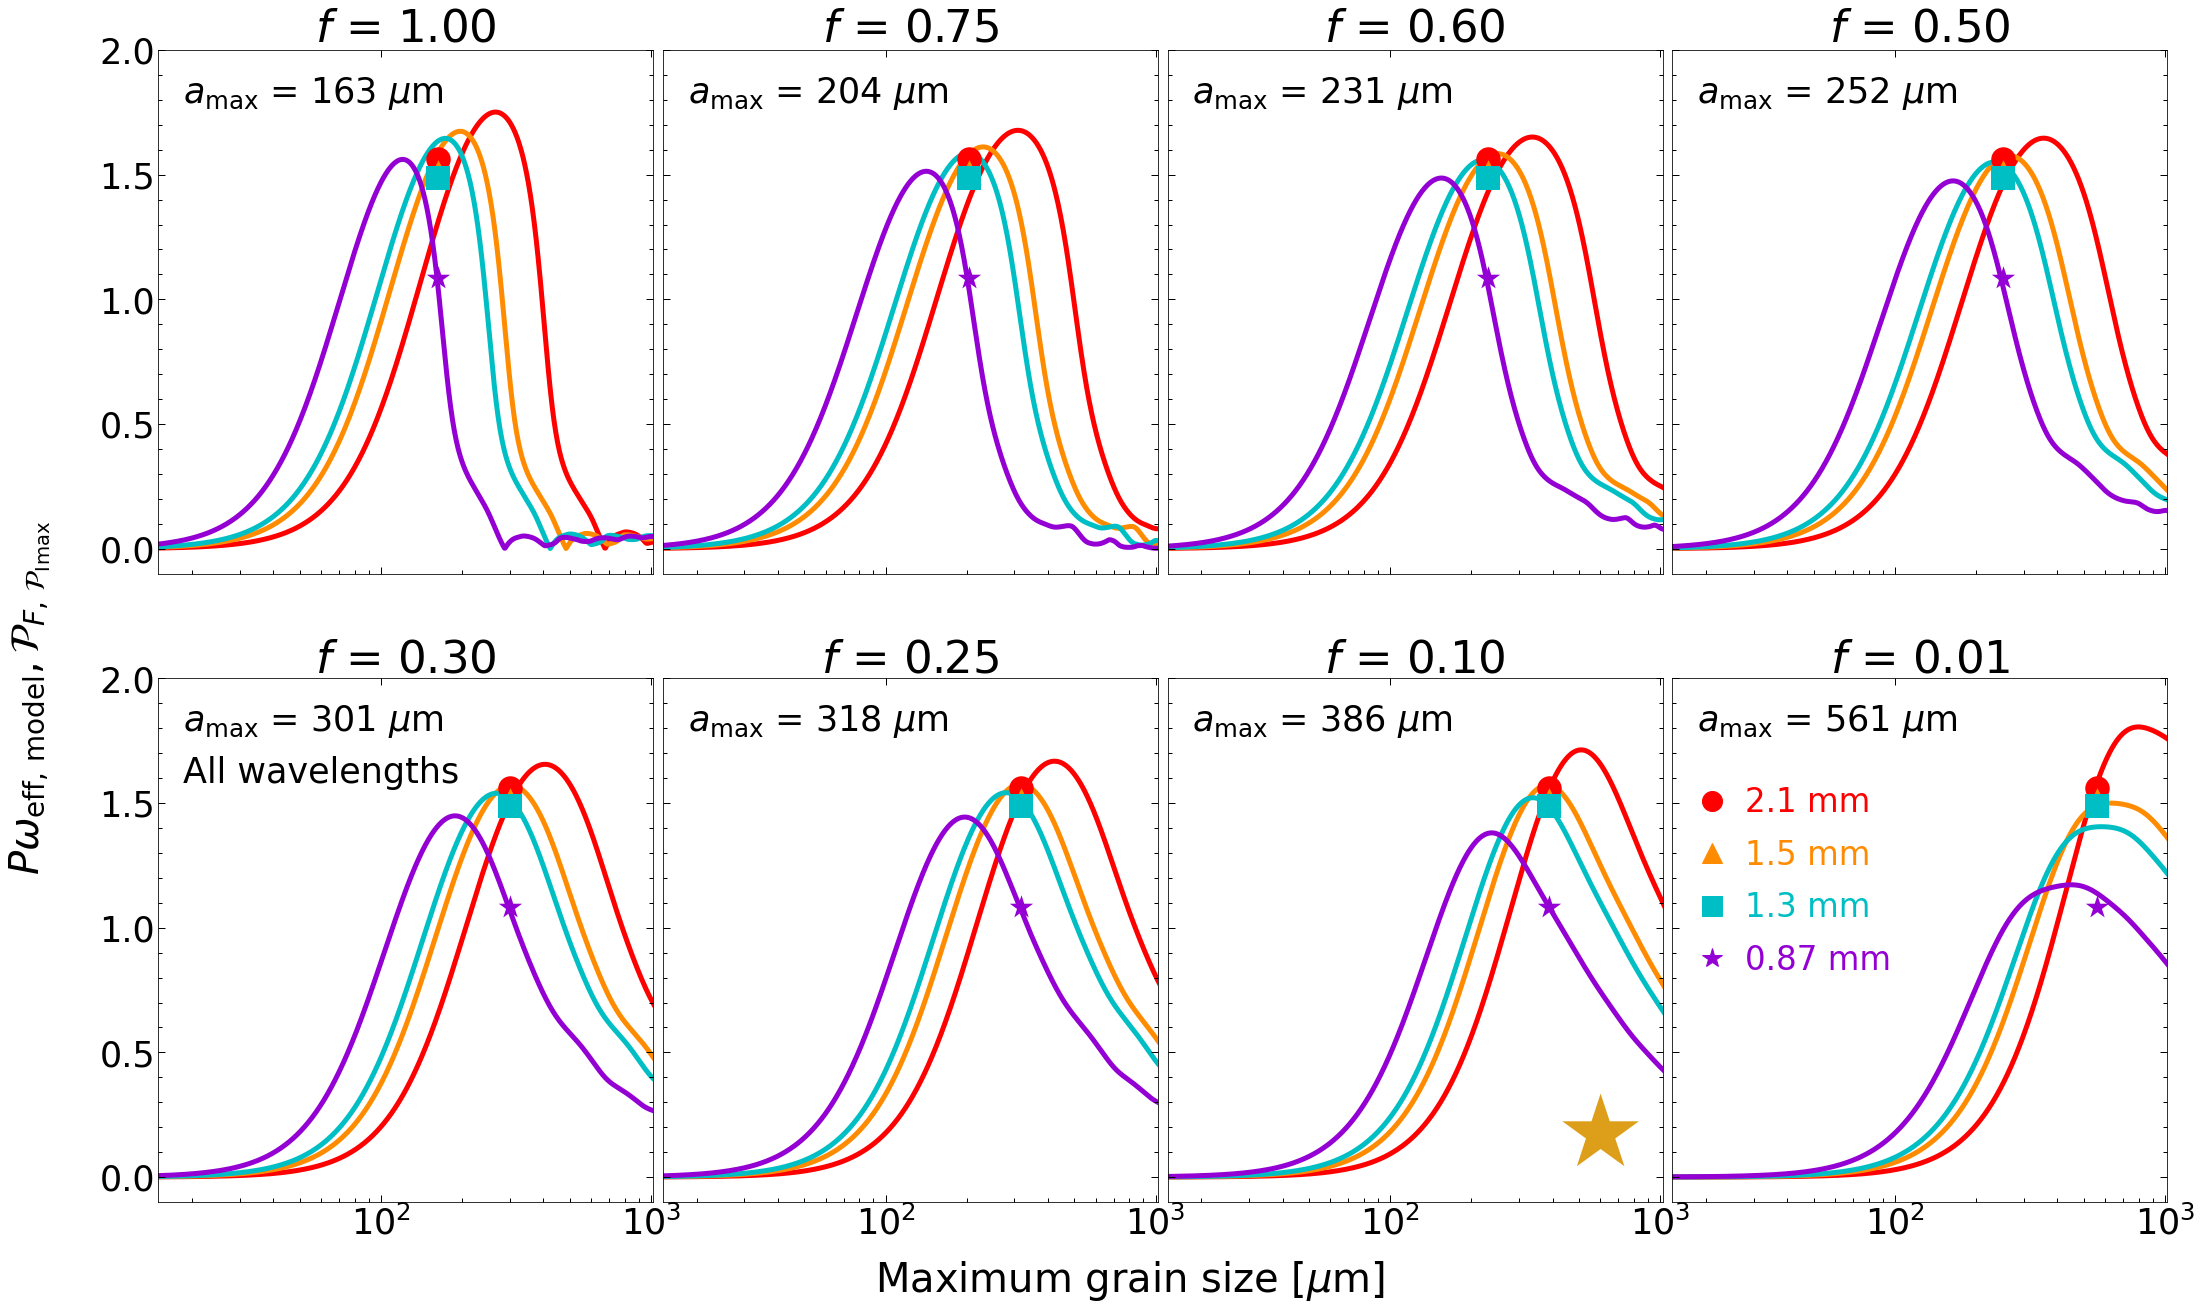

In [30]:
fig, ax = scale_factor_plot_for_writeup_allf(all_bands, 
                                        bands_labels, 
                                        bands_fit, 
                                        f_values_all,                               
                                        a_max_dist_micron_all, 
                                        P_times_omega_all,
                                        best_sf_all, 
                                        best_idx_all, 
                                        a_max_best_all, 
                                        POLF_obs_for_plot,
                                        chi_sq_all,
                                             chi_sq_reduced_all, 
                                             POLF_type,
                                             #y_label_pos = 0.1,
                                             #x_label_pos = -0.02,
#                                              ymin = 0, 
#                                              ymax = 15,
#                                         plot_sf = False,
#                                         plot_chi_sq = False, 
#                                              plot_chi_sq_reduced = False,
                                             legend_loc = 7
#                                         plot_sf = True,
#                                         plot_chi_sq = True, 
#                                              plot_chi_sq_reduced = True, 
                                        )



ax[1, 2].text(
    0.85, 1 - 0.88,
    r'$\star$',
    transform=ax[1, 2].transAxes,
    fontsize=200,
    color= '#dd9e1aff',
    ha='center',
    va='center'
)

ax[1, 0].text(
    0.05, 0.8,
    r'All wavelengths',
    transform=ax[1, 0].transAxes,
    fontsize=35,
    color= 'black',
#     alpha = 0.75, 
#     ha='left',
#     va='center'
)


# ax[1, 0].text(
#     0.05, 0.7,
#     r'$\mathcal{P}_{F,\,\mathrm{POLI}_{\mathrm{max}}}$', 
#     transform=ax[1, 0].transAxes,
#     fontsize=40,
#     color= 'black',
# #     alpha = 0.75, 
# #     ha='left',
# #     va='center'
# )


# Plot lines so I can see if its correct 
plt.savefig(writeup_image_folder_path + '/DustModels/POLF_maxPOLI/' + "DustModelPlot_AllBands_ZhangMethod_ALL_maxPOLI.pdf", 
            dpi=300, 
            bbox_inches='tight')

In [14]:
# raise SystemExit("Stop here")

In [15]:
# raise SystemExit("Stop here")

## No 5

In [16]:
bands_wo5 = ["Band 4 nterms2",  "Band 6", "Band 7 nterms2"]
fit_indices_wo5 = [band_to_index[b] for b in bands_wo5]

a_max_dist_micron_wo5, P_times_omega_wo5, a_max_best_wo5, POLF_obs_wo5, best_sf_wo5, best_idx_wo5, chi_sq_wo5, chi_sq_reduced_wo5, df_best_wo5 = find_sf_v5(
    all_bands,
    bands_naming,
    bands_wo5,
    data,
    f_values_all,
    wavelengths,
    df_POLF,
    POLF_type,
#     choose_trouble_index = True,
#     trouble = True,
#     trouble_f = [0.75], 
#     trouble_index = 2, 
)


df_best_wo5.drop(columns=['Best idx'])

The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 6', 'Band 7 nterms2']
fit_indicies: [0, 2, 3]
 
In find_sf_v5, bands_included_in_fit = ['Band 4 nterms2', 'Band 6', 'Band 7 nterms2'], len(bands_included_in_fit) = 3, chi^2 is scaled by 1 / 2
 
fit_indicies: [0, 2, 3]
 
In find_sf_v5, bands_included_in_fit = ['Band 4 nterms2', 'Band 6', 'Band 7 nterms2'], len(bands_included_in_fit) = 3, chi^2 is scaled by 1 / 2
 
fit_indicies: [0, 2, 3]
 
In find_sf_v5, bands_included_in_fit = ['Band 4 nterms2', 'Band 6', 'Band 7 nterms2'], len(bands_included_in_fit) = 3, chi^2 is scaled by 1 / 2
 
fit_indicies: [0, 2, 3]
 
In find_sf_v5, bands_included_in_fit = ['Band 4 nterms2', 'Band 6', 'Band 7 nterms2'], len(bands_included_in_fit) = 3, chi^2 is scaled by 1 / 2
 
fit_indicies: [0, 2, 3]
 
In find_sf_v5, bands_included_in_fit = ['Band 4 nterms2', 'Band 6', 'Band 7 nterms2'], len(bands_include

,f,Best a_max,Best SF,Best chi^2,Best chi^2 red
0,1.00,164.0,2.59,102.73,51.37
1,0.75,205.0,2.40,51.44,25.72
2,0.60,232.0,2.35,29.11,14.55
3,0.50,253.0,2.37,20.44,10.22
4,0.30,305.0,2.50,6.48,3.24
5,0.25,320.0,2.57,4.15,2.07
6,0.10,389.0,3.21,0.72,0.36
7,0.01,564.0,9.70,17.21,8.60


In [17]:
# fig, ax = scale_factor_plot_for_writeup(all_bands, 
#                                         bands_labels, 
#                                         bands_wo5, 
#                                         f_values,                               
#                                         a_max_dist_micron_wo5, 
#                                         P_times_omega_wo5,
#                                         best_sf_wo5, 
#                                         best_idx_wo5, 
#                                         a_max_best_wo5, 
#                                         POLF_obs_for_plot,
#                                         chi_sq_wo5,
#                                         chi_sq_reduced_wo5,
# #                                         plot_sf = False,
# #                                         plot_chi_sq = False, 
# #                                         plot_chi_sq_reduced = False,
# #                                         plot_sf = True,
# #                                         plot_chi_sq = True, 
# #                                         plot_chi_sq_reduced = True, 
#                                         )
    
    

# ax[1].text(
#     0.85, 0.88,
#     r'$\star$',
#     transform=ax[1].transAxes,
#     fontsize=200,
#     color= '#dd9e1aff',
#     ha='center',
#     va='center'
# )


# # Also want to plot Band 5 data 
# plt.savefig(writeup_image_folder_path + '/DustModels/POLF_maxPOLI/' + "DustModelPlot_Without5_ZhangMethod.pdf", 
#             dpi=300, 
#             bbox_inches='tight')

In [18]:


# fig, ax = scale_factor_plot_for_writeup(all_bands, 
#                                         bands_labels, 
#                                         bands_wo5, 
#                                         f_values_extra,                               
#                                         a_max_dist_micron_wo5, 
#                                         P_times_omega_wo5,
#                                         best_sf_wo5, 
#                                         best_idx_wo5, 
#                                         a_max_best_wo5, 
#                                         POLF_obs_for_plot,
#                                         chi_sq_wo5,
#                                         chi_sq_reduced_wo5,
# #                                         plot_sf = False,
# #                                         plot_chi_sq = False, 
# #                                         plot_chi_sq_reduced = False,
# #                                         plot_sf = True,
# #                                         plot_chi_sq = True, 
# #                                         plot_chi_sq_reduced = True, 
#                                        )
    
    

# # ax[1].text(
# #     0.85, 0.88,
# #     r'$\star$',
# #     transform=ax[1].transAxes,
# #     fontsize=200,
# #     color= '#dd9e1aff',
# #     ha='center',
# #     va='center'
# # )


# # Also want to plot Band 5 data 
# plt.savefig(writeup_image_folder_path + '/DustModels/POLF_maxPOLI/' + "DustModelPlot_Without5_ZhangMethod_Extraf.pdf", 
#             dpi=300, 
#             bbox_inches='tight')

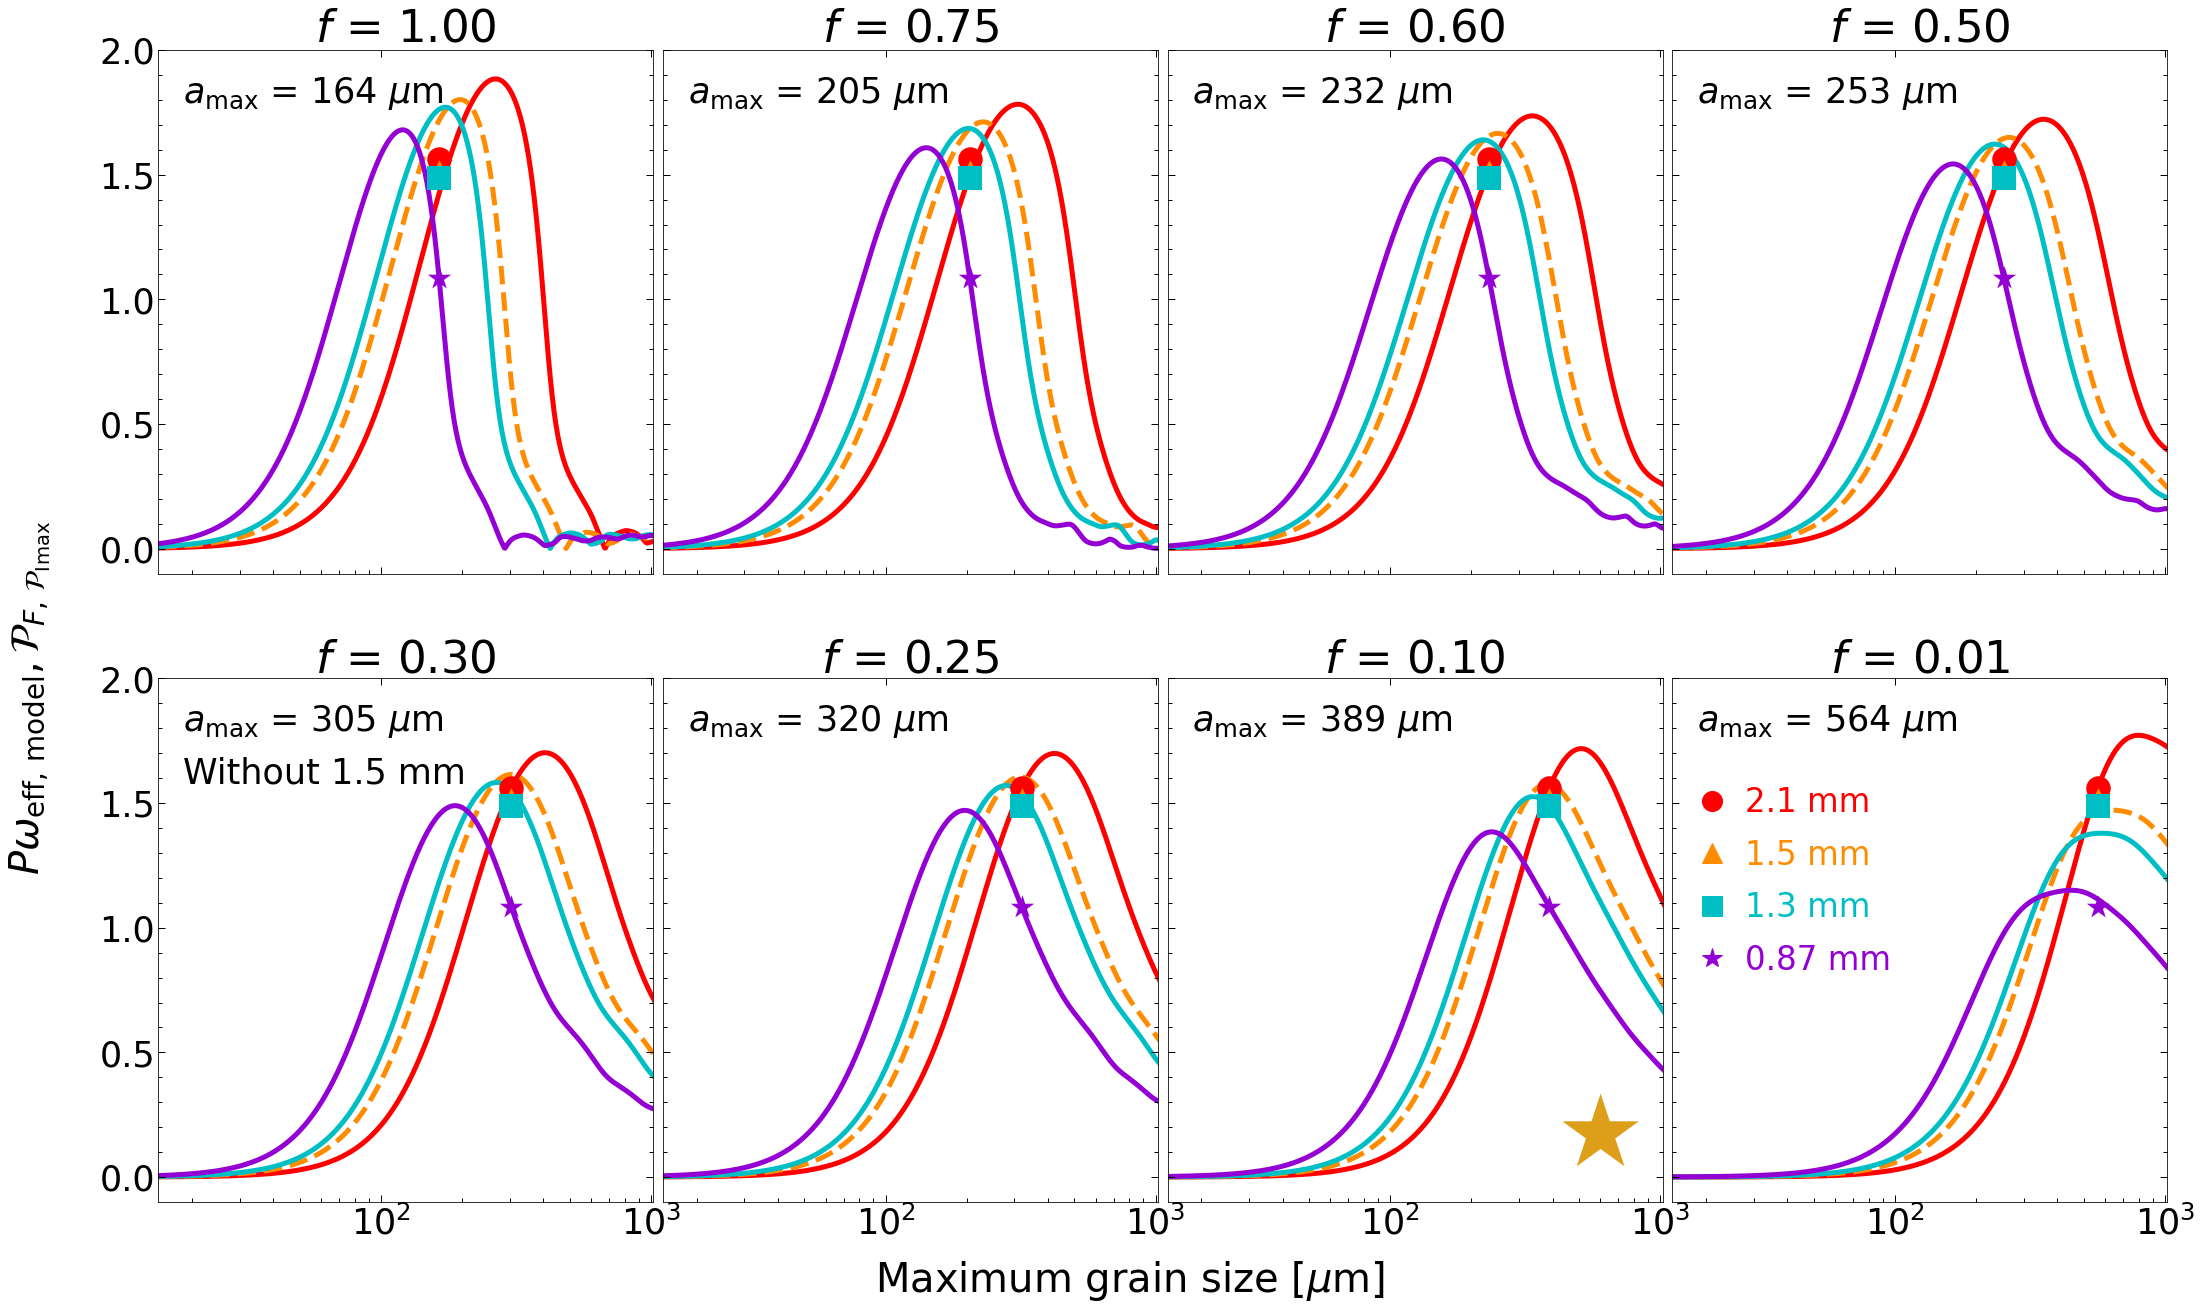

In [29]:
fig, ax = scale_factor_plot_for_writeup_allf(all_bands, 
                                        bands_labels, 
                                        bands_wo5, 
                                        f_values_all,                               
                                        a_max_dist_micron_wo5, 
                                        P_times_omega_wo5,
                                        best_sf_wo5, 
                                        best_idx_wo5, 
                                        a_max_best_wo5, 
                                        POLF_obs_for_plot,
                                        chi_sq_wo5,
                                             chi_sq_reduced_wo5, 
                                             POLF_type,
#                                              ymin = 0, 
#                                              ymax = 15,
#                                         plot_sf = False,
#                                         plot_chi_sq = False, 
#                                              plot_chi_sq_reduced = False,
                                             legend_loc = 7
#                                         plot_sf = True,
#                                         plot_chi_sq = True, 
#                                              plot_chi_sq_reduced = True, 
                                        )



ax[1, 2].text(
    0.85, 1 - 0.88,
    r'$\star$',
    transform=ax[1, 2].transAxes,
    fontsize=200,
    color= '#dd9e1aff',
    ha='center',
    va='center'
)

ax[1, 0].text(
    0.05, 0.8,
    r'Without 1.5 mm',
    transform=ax[1, 0].transAxes,
    fontsize=35,
    color= 'black',
#     alpha = 0.75, 
#     ha='left',
#     va='center'
)


# ax[1, 0].text(
#     0.05, 0.7,
#     r'$\mathcal{P}_{F,\,\mathrm{POLI}_{\mathrm{max}}}$', 
#     transform=ax[1, 0].transAxes,
#     fontsize=40,
#     color= 'black',
# #     alpha = 0.75, 
# #     ha='left',
# #     va='center'
# )


# Plot lines so I can see if its correct 
plt.savefig(writeup_image_folder_path + '/DustModels/POLF_maxPOLI/' + "DustModelPlot_WithoutBand5_ZhangMethod_all_maxPOLI.pdf", 
            dpi=300, 
            bbox_inches='tight')

## No 6

In [20]:
# bands_wo6 = ["Band 4 nterms2", "Band 5 robust -1",  "Band 7 nterms2"]
# fit_indices_wo6 = [band_to_index[b] for b in bands_wo6]


# a_max_dist_micron_wo6, P_times_omega_wo6, a_max_best_wo6, POLF_obs_wo6, best_sf_wo6, best_idx_wo6, chi_sq_wo6, chi_sq_reduced_wo6, df_best_wo6 = find_sf_v5(
#     all_bands,
#     bands_naming,
#     bands_wo6,
#     data,
#     f_values_all,
#     wavelengths,
#     df_POLF,
#     POLF_type
# )

# df_best_wo6

In [21]:
# fig, ax = scale_factor_plot_for_writeup(all_bands, 
#                                         bands_labels, 
#                                         bands_wo6, 
#                                         f_values,                               
#                                         a_max_dist_micron_wo6, 
#                                         P_times_omega_wo6,
#                                         best_sf_wo6, 
#                                         best_idx_wo6, 
#                                         a_max_best_wo6, 
#                                         POLF_obs_for_plot,
#                                         chi_sq_wo6,
#                                         chi_sq_reduced_wo6,
# #                                         plot_sf = False,
# #                                         plot_chi_sq = False, 
# #                                         plot_chi_sq_reduced = False,
# #                                         plot_sf = True,
# #                                         plot_chi_sq = True, 
# #                                         plot_chi_sq_reduced = True,                                         
#                                         )


# ax[1].text(
#     0.85, 0.88,
#     r'$\star$',
#     transform=ax[1].transAxes,
#     fontsize=200,
#     color= '#dd9e1aff',
#     ha='center',
#     va='center'
# )


# # Also want to plot Band 6 data 
# plt.savefig(writeup_image_folder_path + '/DustModels/POLF_maxPOLI/' + "DustModelPlot_Without6_ZhangMethod.pdf", 
#             dpi=300, 
#             bbox_inches='tight')


## Just 4, 7

In [22]:
bands_just_47 = ["Band 4 nterms2",   "Band 7 nterms2"]
fit_indices_just_47 = [band_to_index[b] for b in bands_just_47]


a_max_dist_micron_just_47, P_times_omega_just_47, a_max_best_just_47, POLF_obs_just_47, best_sf_just_47, best_idx_just_47, chi_sq_just_47, chi_sq_reduced_just_47, df_best_just_47 = find_sf_v5(
    all_bands,
    bands_naming,
    bands_just_47,
    data,
    f_values_all,
    wavelengths,
    df_POLF,
    POLF_type,
    choose_trouble_index = True,
    trouble = True,
    trouble_f = [0.5, 0.25], 
    trouble_index = 1, 
)

df_best_just_47.drop(columns=['Best idx'])

The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 7 nterms2']
fit_indicies: [0, 3]
 
In find_sf_v5, bands_included_in_fit = ['Band 4 nterms2', 'Band 7 nterms2'], len(bands_included_in_fit) = 2, chi^2 is scaled by 1 / 1
 
fit_indicies: [0, 3]
 
In find_sf_v5, bands_included_in_fit = ['Band 4 nterms2', 'Band 7 nterms2'], len(bands_included_in_fit) = 2, chi^2 is scaled by 1 / 1
 
fit_indicies: [0, 3]
 
In find_sf_v5, bands_included_in_fit = ['Band 4 nterms2', 'Band 7 nterms2'], len(bands_included_in_fit) = 2, chi^2 is scaled by 1 / 1
 
fit_indicies: [0, 3]
trouble f = [0.5, 0.25]
The best a_max is: 2293.3741683493054
At this value, the best sf is : 23.617563107620597
 
The second best a_max is: 254.7456762552761
At this value, the best sf is : 2.394234315707328
 
The third best a_max is: 2487.338095469149
At this value, the best sf is : 24.026131307581743
 
The fourth best a_max i

,f,Best a_max,Best SF,Best chi^2,Best chi^2 red
0,1.00,167.0,2.79,214.34,214.34
1,0.75,207.0,2.48,81.16,81.16
2,0.60,235.0,2.41,43.52,43.52
3,0.50,255.0,2.39,25.87,25.87
4,0.30,305.0,2.50,6.92,6.92
5,0.25,320.0,2.57,4.43,4.43
6,0.10,389.0,3.21,0.70,0.70
7,0.01,580.0,9.51,21.04,21.04


In [23]:
# fig, ax = scale_factor_plot_for_writeup(all_bands, 
#                                         bands_labels, 
#                                         bands_just_47, 
#                                         f_values,                               
#                                         a_max_dist_micron_just_47, 
#                                         P_times_omega_just_47,
#                                         best_sf_just_47, 
#                                         best_idx_just_47, 
#                                         a_max_best_just_47, 
#                                         POLF_obs_for_plot,
#                                         chi_sq_just_47,
#                                         chi_sq_reduced_just_47,
# #                                         plot_sf = False,
# #                                         plot_chi_sq = False, 
# #                                         plot_chi_sq_reduced = False,
# #                                         plot_sf = True,
# #                                         plot_chi_sq = True, 
# #                                         fig_x = 30, fig_y = 10,
# #                                         plot_chi_sq_reduced = True, 
#                                        )

# ax[1].text(
#     0.85, 0.88,
#     r'$\star$',
#     transform=ax[1].transAxes,
#     fontsize=200,
#     color= '#dd9e1aff',
#     ha='center',
#     va='center'
# )


# plt.savefig(writeup_image_folder_path + '/DustModels/POLF_maxPOLI/' + "DustModelPlot_Just47_ZhangMethod.pdf", 
#             dpi=300, 
#             bbox_inches='tight')

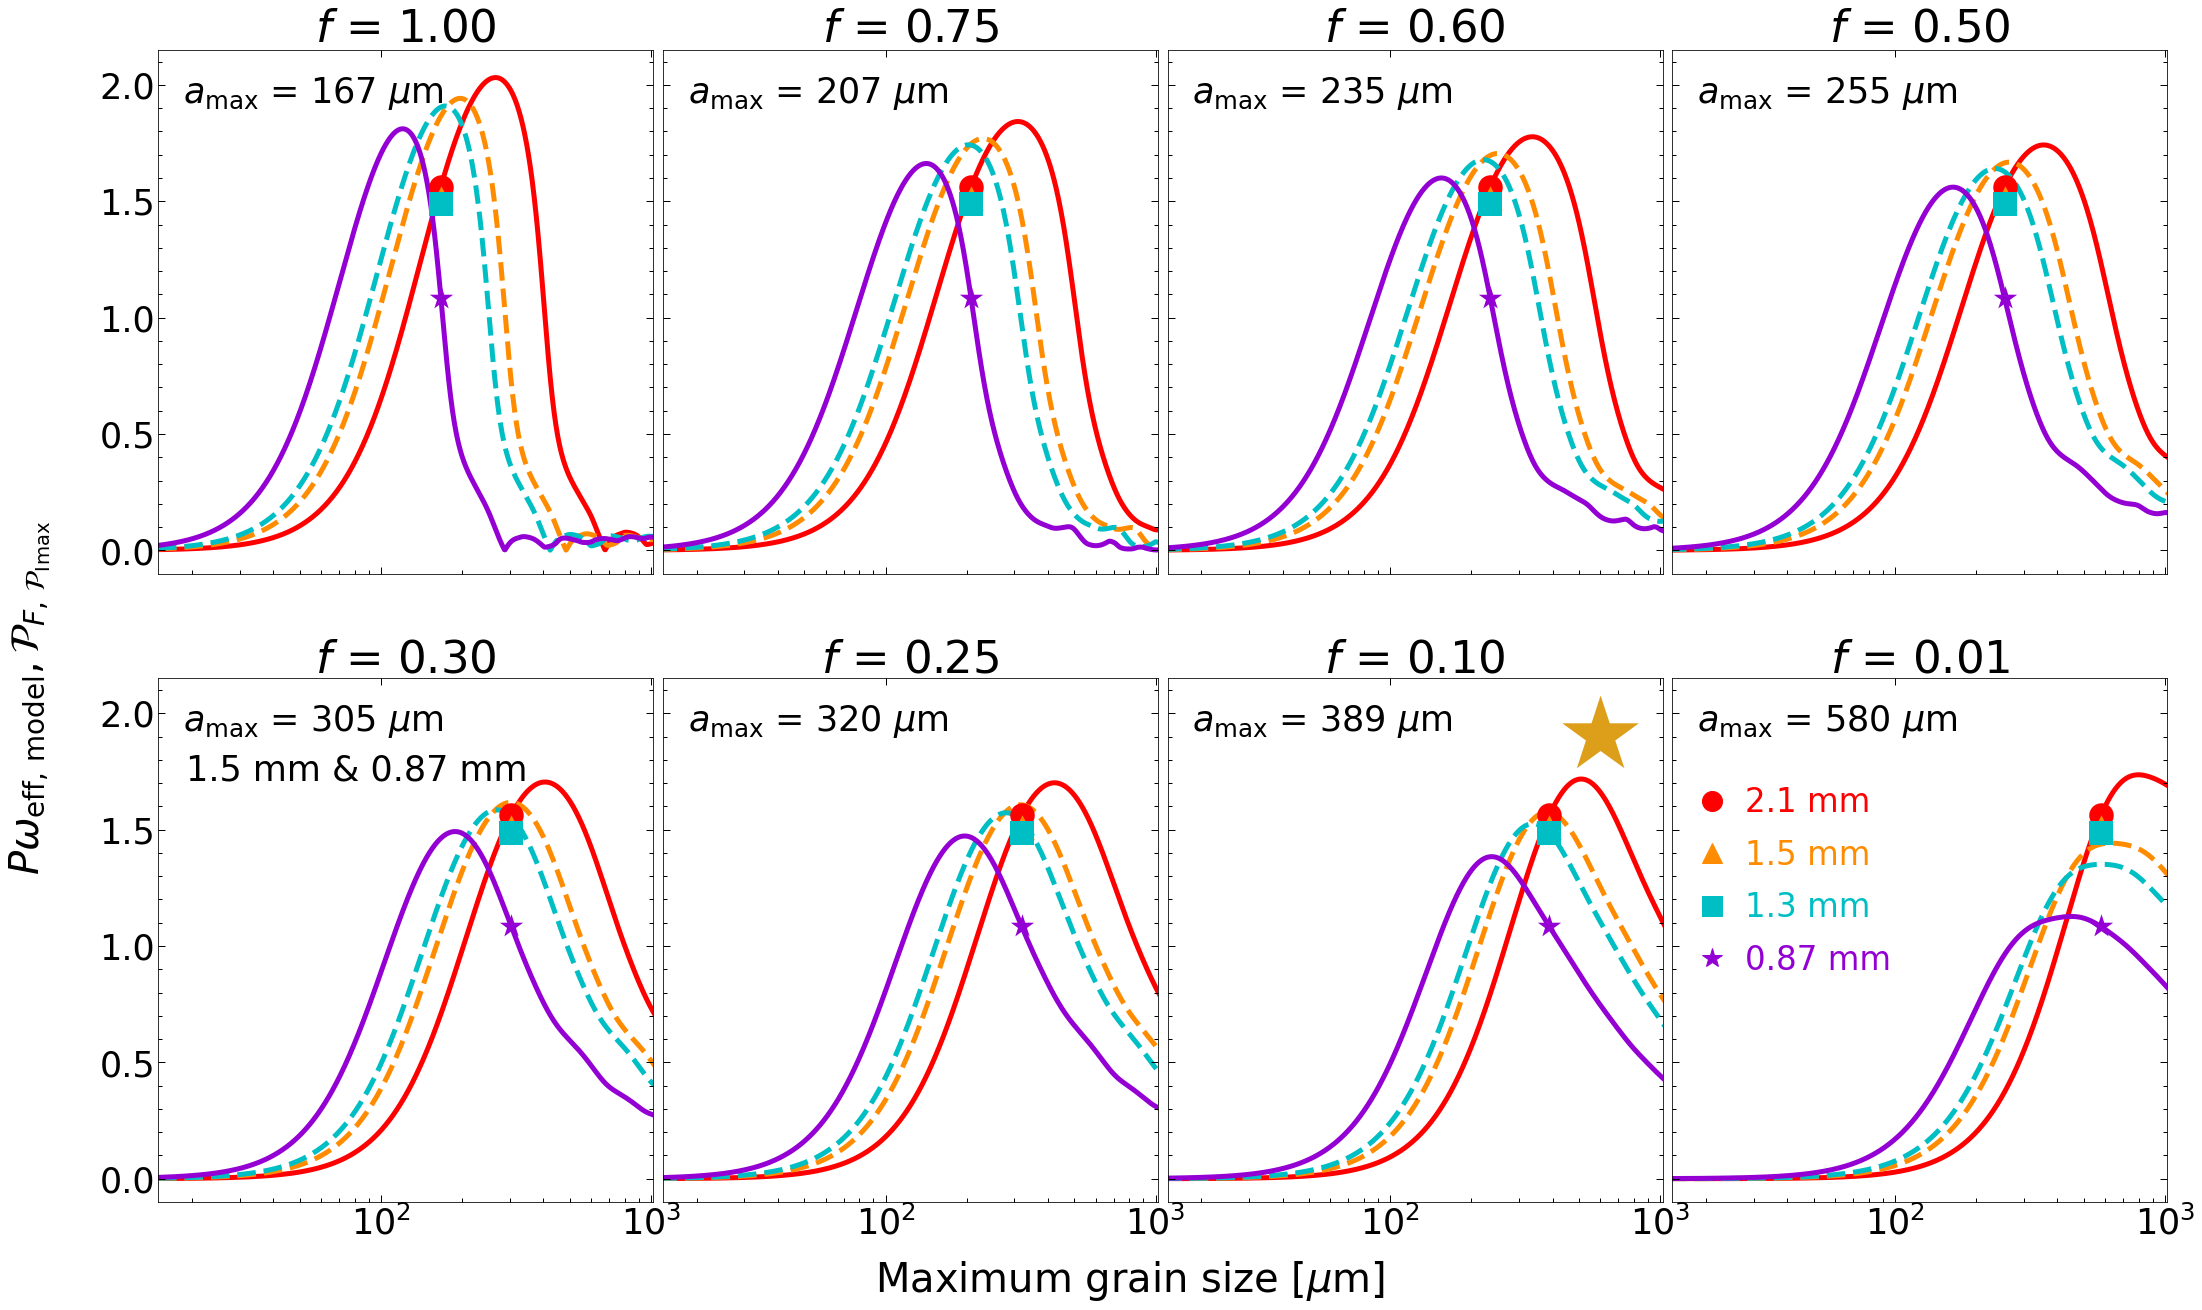

In [28]:
fig, ax = scale_factor_plot_for_writeup_allf(all_bands, 
                                        bands_labels, 
                                        bands_just_47, 
                                        f_values_all,                               
                                        a_max_dist_micron_just_47, 
                                        P_times_omega_just_47,
                                        best_sf_just_47, 
                                        best_idx_just_47, 
                                        a_max_best_just_47, 
                                        POLF_obs_for_plot,
                                        chi_sq_just_47,
                                             chi_sq_reduced_just_47, 
                                             POLF_type,
                                             ymax = 2.15,
                                        #plot_sf = True,
#                                         plot_chi_sq = False,
#                                              plot_chi_sq_reduced = False,
                                             legend_loc = 7, 
#                                         plot_sf = True,
#                                         plot_chi_sq = True, 
#                                         fig_x = 30, fig_y = 10,
#                                         plot_chi_sq_reduced = True, 
                                            )

ax[1, 2].text(
    0.85, 0.88,
    r'$\star$',
    transform=ax[1, 2].transAxes,
    fontsize=200,
    color= '#dd9e1aff',
    ha='center',
    va='center'
)


ax[1, 0].text(
    0.40, 0.825,
    r'1.5 mm & 0.87 mm',
    transform=ax[1, 0].transAxes,
    fontsize=35,
    color= 'black',
#     alpha = 0.75, 
    ha='center',
    va='center'
)

# ax[1, 0].text(
#     0.05, 0.7,
#     r'$\mathcal{P}_{F,\,\mathrm{POLI}_{\mathrm{max}}}$', 
#     transform=ax[1, 0].transAxes,
#     fontsize=40,
#     color= 'black',
# #     alpha = 0.75, 
# #     ha='left',
# #     va='center'
# )

plt.savefig(writeup_image_folder_path + '/DustModels/POLF_maxPOLI/' + "DustModelPlot_Just47_ZhangMethod_ALL_maxPOLI.pdf", 
            dpi=300, 
            bbox_inches='tight')

# Success vs porosity

In [25]:
dfs = [df_best_all, df_best_wo5, df_best_just_47]



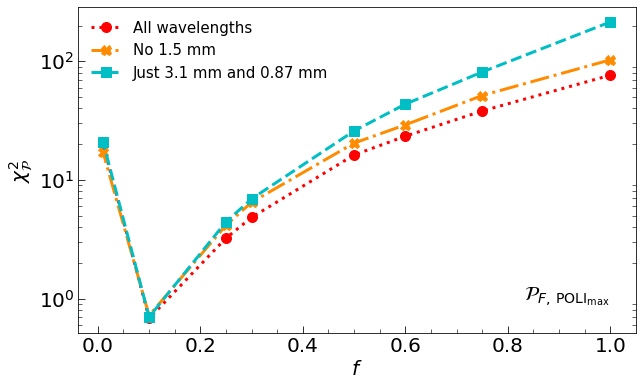

In [26]:
labels = ['All wavelengths', 'No 1.5 mm', 'Just 3.1 mm and 0.87 mm']
c = [alma_band_colors[4], alma_band_colors[5], alma_band_colors[6]]
ms = ['o', 'X', 's']
ls = [':', 'dashdot', '--']

fig, ax = plt.subplots(figsize=(10, 6))


for i, df in enumerate(dfs):
    
    ax.plot(df['f'], 
            df['Best chi^2'], 
            marker = ms[i],
           label = labels[i],
           color = c[i],
           lw = 3,
           ms = 10,
           ls = ls[i])

ax.set_xlabel('$f$', fontsize=axis_label_fs)
ax.set_ylabel(r'$\chi_\mathcal{P}^2$', fontsize=axis_label_fs)


# Ticks
ax.minorticks_on()

ax.tick_params(axis="x", which="minor",
               direction="in", left=True, right=True, length=4)
ax.tick_params(axis="y", which="minor",
               direction="in", left=True, right=True, length=4)

ax.tick_params(axis="x", which="major",
               direction="in", bottom=True, top=False,
               length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major",
               direction="in", left=True, right=False,
               length=7, labelsize=axis_num_fs)

ax.legend(fontsize=legend_text_fs, frameon=False)

ax.set_yscale('log')

ax.text(
    0.8, 0.1,
    r'$\mathcal{P}_{F,\,\mathrm{POLI}_{\mathrm{max}}}$', 
    transform=ax.transAxes,
    fontsize=20,
    color= 'black',
#     alpha = 0.75, 
#     ha='left',
#     va='center'
)


plt.savefig(writeup_image_folder_path + '/DustModels/POLF_maxPOLI/' + "chi_fs_f_maxPOLI.pdf", 
            dpi=300, 
            bbox_inches='tight')

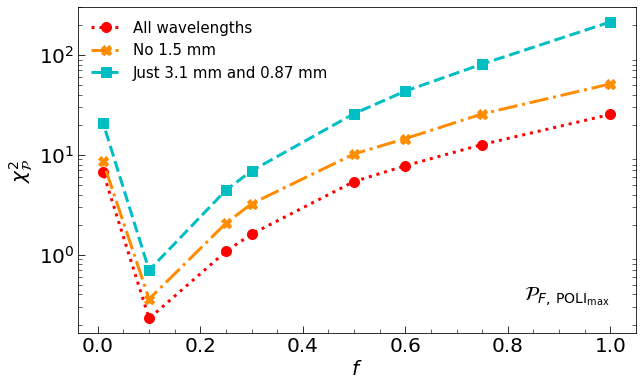

In [27]:
labels = ['All wavelengths', 'No 1.5 mm', 'Just 3.1 mm and 0.87 mm']
c = [alma_band_colors[4], alma_band_colors[5], alma_band_colors[6]]
ms = ['o', 'X', 's']
ls = [':', 'dashdot', '--']

fig, ax = plt.subplots(figsize=(10, 6))


for i, df in enumerate(dfs):
    
    ax.plot(df['f'], 
            df['Best chi^2 red'], 
            marker = ms[i],
           label = labels[i],
           color = c[i],
           lw = 3,
           ms = 10,
           ls = ls[i])

ax.set_xlabel('$f$', fontsize=axis_label_fs)
ax.set_ylabel(r'$\chi_\mathcal{P}^2$', fontsize=axis_label_fs)


# Ticks
ax.minorticks_on()

ax.tick_params(axis="x", which="minor",
               direction="in", left=True, right=True, length=4)
ax.tick_params(axis="y", which="minor",
               direction="in", left=True, right=True, length=4)

ax.tick_params(axis="x", which="major",
               direction="in", bottom=True, top=False,
               length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major",
               direction="in", left=True, right=False,
               length=7, labelsize=axis_num_fs)

ax.legend(fontsize=legend_text_fs, frameon=False)

ax.set_yscale('log')


ax.text(
    0.8, 0.1,
    r'$\mathcal{P}_{F,\,\mathrm{POLI}_{\mathrm{max}}}$', 
    transform=ax.transAxes,
    fontsize=20,
    color= 'black',
#     alpha = 0.75, 
#     ha='left',
#     va='center'
)

plt.savefig(writeup_image_folder_path + '/DustModels/POLF_maxPOLI/' + "chi_fs_f_reduced_maxPOLI.pdf", 
            dpi=300, 
            bbox_inches='tight')